# Project 6: Simple Neural Network Forward Propagation

Name: Prakruthi BR

Registration No: 2411021240038

Subject: Deep Learning

Topic: Simple Neural Network Forward Propagation
## Objective

The objective of this project is to create a basic neural network using the Iris classification dataset.

The project demonstrates how input features pass through a neural network using forward propagation and how the network generates predictions for different Iris flower species.

### Tasks

1. Load and prepare the Iris dataset for classification.
2. Build a simple neural network and perform forward propagation using Python.
3. Apply activation functions and display the predicted output.

## Task 1: Loading and Preparing the Iris Dataset

First, we import the required libraries.

NumPy is used for numerical calculations, Pandas is used to display the dataset, and Scikit-learn is used to load the Iris dataset.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)

Input shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


### Understanding the Dataset

The Iris dataset contains 150 flower samples.

Each flower has four input features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

There are three possible output classes:

- Setosa
- Versicolor
- Virginica

In [ ]:
df = pd.DataFrame(
    X,
    columns=[
        "Sepal Length",
        "Sepal Width",
        "Petal Length",
        "Petal Width"
    ]
)

df["Species"] = [iris.target_names[i] for i in y]

df.head(10)

,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## Task 2: Building a Simple Neural Network

A simple neural network is created with three layers:

- Input Layer: 4 neurons
- Hidden Layer: 5 neurons
- Output Layer: 3 neurons

The four input neurons represent the four Iris features.

The three output neurons represent the three Iris flower species.

### Network Structure

Input Layer → Hidden Layer → Output Layer

4 neurons → 5 neurons → 3 neurons

### Initializing Weights and Biases

Weights determine how strongly the input values affect the neurons.

Biases are added to the weighted sum before applying the activation function.

The weights are initialized with small random values.

In [ ]:
np.random.seed(42)

# Input layer to hidden layer
W1 = np.random.randn(4, 5) * 0.1
b1 = np.zeros((1, 5))

# Hidden layer to output layer
W2 = np.random.randn(5, 3) * 0.1
b2 = np.zeros((1, 3))

print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (4, 5)
b1 shape: (1, 5)
W2 shape: (5, 3)
b2 shape: (1, 3)


### Forward Propagation

Forward propagation is the process of passing the input data through the neural network to produce an output.

First, the input is multiplied by the weights of the hidden layer and the bias is added.

Z1 = XW1 + b1

The result is passed through an activation function.

Then the hidden layer output is passed to the output layer.

Z2 = A1W2 + b2

Finally, an activation function is applied to obtain the final output.

In [ ]:
# Use the first 5 samples for demonstration
X_sample = X[:5]

# Input layer to hidden layer
Z1 = np.dot(X_sample, W1) + b1

print("Hidden layer weighted output:")
print(Z1)

Hidden layer weighted output:
[[ 0.09525206  0.3967509   0.63908297  0.32640948 -0.19925678]
 [ 0.09702462  0.32055555  0.58775747  0.3194226  -0.22170171]
 [ 0.08704178  0.35956239  0.58773277  0.29870532 -0.18891826]
 [ 0.07514765  0.33583831  0.57842078  0.24990416 -0.22650069]
 [ 0.08794354  0.41392568  0.64028044  0.30648443 -0.19148964]]


## Task 3: Applying Activation Functions

### ReLU Activation Function

ReLU stands for Rectified Linear Unit.

The ReLU function converts negative values to zero and keeps positive values unchanged.

Formula:

ReLU(x) = max(0, x)

It is applied to the hidden layer.

In [ ]:
def relu(x):
    return np.maximum(0, x)

A1 = relu(Z1)

print("Output after ReLU activation:")
print(A1)

Output after ReLU activation:
[[0.09525206 0.3967509  0.63908297 0.32640948 0.        ]
 [0.09702462 0.32055555 0.58775747 0.3194226  0.        ]
 [0.08704178 0.35956239 0.58773277 0.29870532 0.        ]
 [0.07514765 0.33583831 0.57842078 0.24990416 0.        ]
 [0.08794354 0.41392568 0.64028044 0.30648443 0.        ]]


### Softmax Activation Function

Softmax is used in the output layer for classification.

It converts the output values into probabilities.

The three output values represent:

- Setosa
- Versicolor
- Virginica

The class with the highest probability is selected as the prediction.

In [ ]:
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [ ]:
# Hidden layer to output layer
Z2 = np.dot(A1, W2) + b2

# Apply Softmax
A2 = softmax(Z2)

print("Output probabilities:")
print(A2)

Output probabilities:
[[0.30514149 0.33935342 0.35550509]
 [0.30843104 0.33803107 0.35353789]
 [0.30751006 0.33896891 0.35352104]
 [0.30891427 0.3405217  0.35056403]
 [0.30483296 0.34021549 0.35495155]]


## Predicted Output

The Softmax function produces probabilities for the three Iris species.

The `argmax()` function identifies the class with the highest probability.

The predicted class is then converted into the corresponding Iris species name.

In [ ]:
predictions = np.argmax(A2, axis=1)

print("Predicted class numbers:")
print(predictions)

print("\nPredicted Iris species:")

for prediction in predictions:
    print(iris.target_names[prediction])

Predicted class numbers:
[2 2 2 2 2]

Predicted Iris species:
virginica
virginica
virginica
virginica
virginica


In [ ]:
prediction_table = pd.DataFrame(
    A2,
    columns=iris.target_names
)

prediction_table["Predicted Species"] = [
    iris.target_names[i] for i in predictions
]

prediction_table

,setosa,versicolor,virginica,Predicted Species
0,0.305141,0.339353,0.355505,virginica
1,0.308431,0.338031,0.353538,virginica
2,0.307510,0.338969,0.353521,virginica
3,0.308914,0.340522,0.350564,virginica
4,0.304833,0.340215,0.354952,virginica


## Result

The Iris dataset was successfully loaded and used as input to a simple neural network.

Forward propagation was performed by passing the input features through the hidden layer and output layer.

ReLU activation was applied to the hidden layer, while Softmax activation was applied to the output layer.

The final output contains probabilities for Setosa, Versicolor, and Virginica, and the class with the highest probability is selected as the predicted Iris species.

# Expected Output / Result

The neural network successfully performs forward propagation on the Iris dataset.

The network generates classification predictions for the three Iris flower species:

- Setosa
- Versicolor
- Virginica

The forward propagation process is demonstrated by passing the input features through the hidden layer, applying ReLU activation, passing the result to the output layer, and applying Softmax activation to obtain the final classification probabilities.

The Iris flower species with the highest probability is selected as the predicted class.

In [11]:
print("Classification Predictions for Iris Flowers:")
print("---------------------------------------------")

for i in range(len(predictions)):
    print(
        f"Sample {i+1}: "
        f"{iris.target_names[predictions[i]]}"
    )

Classification Predictions for Iris Flowers:
---------------------------------------------
Sample 1: virginica
Sample 2: virginica
Sample 3: virginica
Sample 4: virginica
Sample 5: virginica


## Activation Function Comparison

ReLU and Softmax are used at different stages of the neural network.

- **ReLU:** Used in the hidden layer to introduce non-linearity.
- **Softmax:** Used in the output layer to convert values into class probabilities.

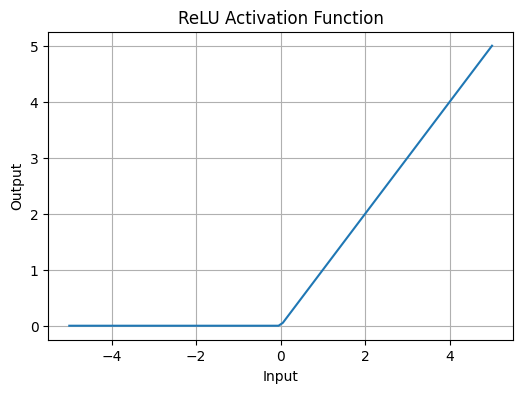

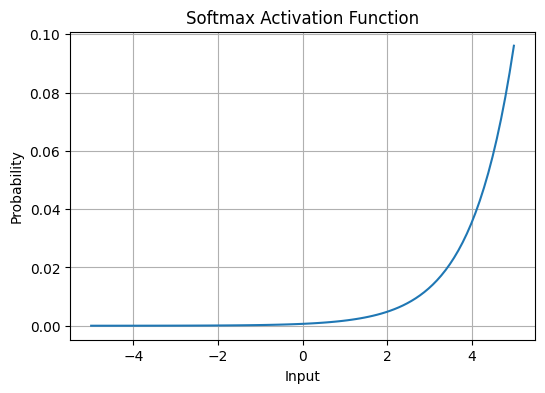

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ReLU
x = np.linspace(-5, 5, 100)
relu = np.maximum(0, x)

# Softmax for 3 classes
z = np.linspace(-5, 5, 100)
exp_values = np.exp(z - np.max(z))
softmax = exp_values / np.sum(exp_values)

# Plot ReLU
plt.figure(figsize=(6, 4))
plt.plot(x, relu)
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.show()

# Plot Softmax
plt.figure(figsize=(6, 4))
plt.plot(z, softmax)
plt.title("Softmax Activation Function")
plt.xlabel("Input")
plt.ylabel("Probability")
plt.grid(True)
plt.show()